# Fair Clustering Evaluation using FACROC

This notebook runs the implementation, training, and evaluation of **5 clustering algorithms** on **6 benchmark datasets** under the **FACROC** (Fairness Area under the Curve for ROC of Clustering) fairness evaluation metric.

### Algorithms (implemented from scratch):
1. **K-Means Scratch**: Standard centroid-based clustering with K-Means++ initialization.
2. **Hierarchical Scratch**: Agglomerative clustering with Ward's linkage.
3. **Fairlet Scratch**: Traditional Fairlet Decomposition for demographic balance.
4. **Scalable Fair Scratch**: Improved KD-Tree based Fairlet Decomposition for large datasets.
5. **Proportional Fair Scratch**: Center-based clustering with individual representation bounds.

### Datasets:
- **Adult**, **German Credit**, **COMPAS**, **Credit Card**, **Student Math**, **Student Portuguese**.

---

## 1. Initialization and Imports

We configure our path variables to import custom modules from the `src/` directory and import standard scientific libraries.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

# Add project root to sys.path so we can import src modules
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(os.path.join(project_root, "src", "utils"))
sys.path.append(os.path.join(project_root, "src", "models"))

from data_loader import load_compas
from facroc import aucc, compute_facroc, interpolate_roc_curve

# Import custom scratch clustering algorithms
from kmeans import KMeansScratch
from hierarchical import HierarchicalScratch
from fairlet import FairletClusteringScratch
from scalable_fair import ScalableFairClusteringScratch
from proportional_fair import ProportionallyFairClusteringScratch

## 2. PCA-based Clustering Visualization on COMPAS

To verify the algorithms are working correctly, we train all 5 models on the COMPAS dataset ($K = 7$) and use PCA (implemented from scratch using NumPy) to project features to 2D for visualization.

Loading COMPAS dataset...
Training models with K = 7...


Plotting comparisons...


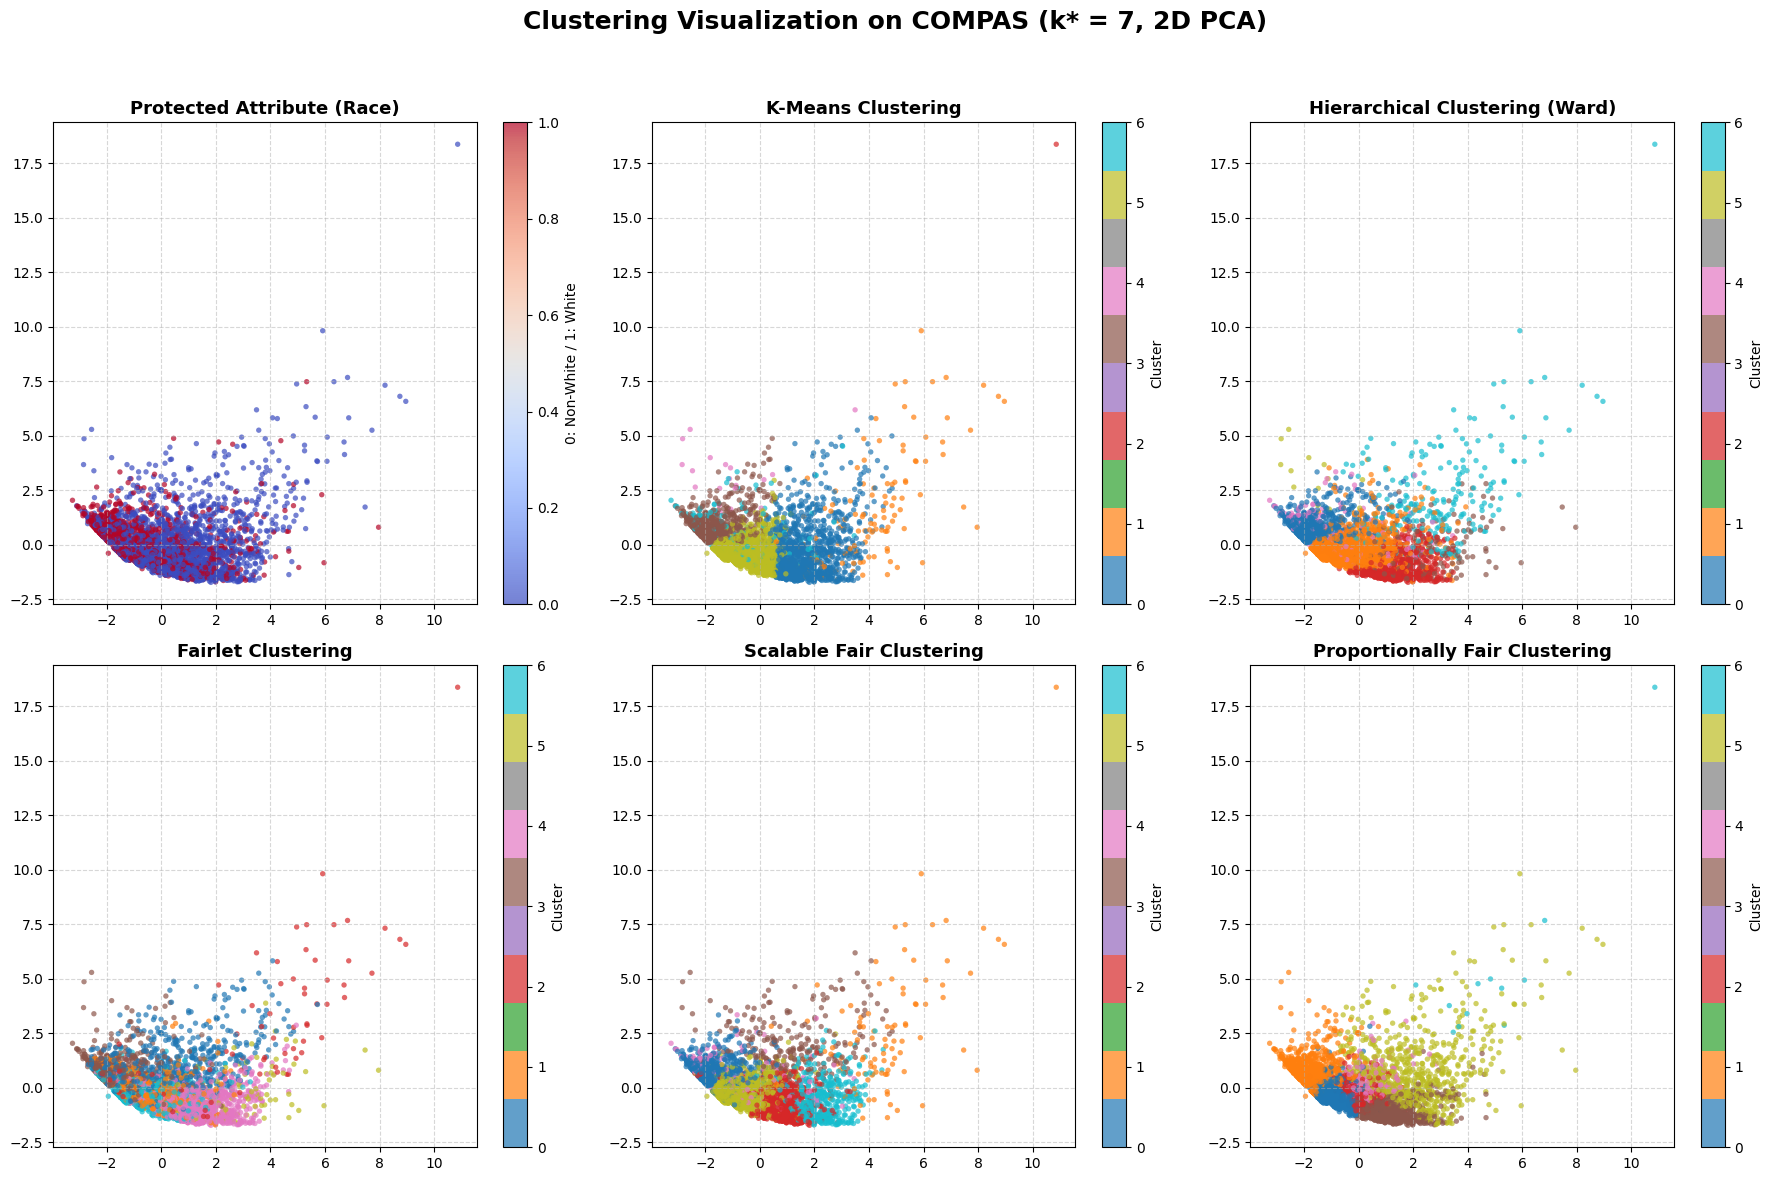

In [2]:
# 1. PCA implementation from scratch using NumPy
def pca_scratch(X, n_components=2):
    X_centered = X - np.mean(X, axis=0)
    cov = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]
    W = eigenvectors[:, :n_components]
    return np.dot(X_centered, W)

# 2. Load COMPAS dataset
print("Loading COMPAS dataset...")
X_df, P = load_compas()
X = X_df.values

# Project features to 2D space
X_2d = pca_scratch(X, 2)

# 3. Train all 5 clustering models with optimal K = 7
k_star = 7
print(f"Training models with K = {k_star}...")
km = KMeansScratch(n_clusters=k_star, random_state=42).fit(X)
hc = HierarchicalScratch(n_clusters=k_star).fit(X)
fc = FairletClusteringScratch(n_clusters=k_star, random_state=42).fit(X, P)
sfc = ScalableFairClusteringScratch(n_clusters=k_star, random_state=42).fit(X, P)
pfc = ProportionallyFairClusteringScratch(n_clusters=k_star, random_state=42).fit(X)

# 4. Plot comparison side-by-side (2 rows x 3 columns)
print("Plotting comparisons...")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f"Clustering Visualization on COMPAS (k* = {k_star}, 2D PCA)", fontsize=18, fontweight='bold')

def plot_scatter(ax, labels, title, cbar_label="Cluster", cmap='tab10'):
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap=cmap, alpha=0.7, edgecolors='none', s=15)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(cbar_label)

# Row 1
plot_helper = lambda ax, labels, title, cbar_label="Cluster", cmap='tab10': plot_scatter(ax, labels, title, cbar_label, cmap)
plot_helper(axes[0, 0], P, "Protected Attribute (Race)", "0: Non-White / 1: White", cmap='coolwarm')
plot_helper(axes[0, 1], km.labels, "K-Means Clustering")
plot_helper(axes[0, 2], hc.labels, "Hierarchical Clustering (Ward)")

# Row 2
plot_helper(axes[1, 0], fc.labels, "Fairlet Clustering")
plot_helper(axes[1, 1], sfc.labels, "Scalable Fair Clustering")
plot_helper(axes[1, 2], pfc.labels, "Proportionally Fair Clustering")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 3. Complete Benchmark Experiments

We run all 5 clustering models across all 6 preprocessed datasets. 

**Note on RAM safety:** For slow algorithms (Hierarchical, Fairlet, Scalable, Proportional) running on large datasets ($N > 5000$ like Adult and Credit Card), we subsample the dataset to 3000 instances to prevent CPU/RAM memory overflow. Similarly, we limit the maximum samples to 3000 per group when plotting ROC curves to match the methodology in the paper.

In [3]:
# 1. Define dataset configurations
datasets = [
    {
        "name": "Adult", 
        "file": "dataset/processed/adult_processed.csv", 
        "p_attr": "protected_attribute", 
        "p_group": 0, "np_group": 1, 
        "p_label": "Female", "np_label": "Male",
        "k": 2
    },
    {
        "name": "German Credit", 
        "file": "dataset/processed/german_processed.csv", 
        "p_attr": "protected_attribute", 
        "p_group": 0, "np_group": 1, 
        "p_label": "Female", "np_label": "Male",
        "k": 2
    },
    {
        "name": "COMPAS", 
        "file": "dataset/processed/compas_processed.csv", 
        "p_attr": "protected_attribute", 
        "p_group": 0, "np_group": 1, 
        "p_label": "Non-White", "np_label": "White",
        "k": 7
    },
    {
        "name": "Credit Card", 
        "file": "dataset/processed/credit_card_processed.csv", 
        "p_attr": "protected_attribute", 
        "p_group": 0, "np_group": 1, 
        "p_label": "Female", "np_label": "Male",
        "k": 2
    },
    {
        "name": "Student Math", 
        "file": "dataset/processed/student_mat_processed.csv", 
        "p_attr": "protected_attribute", 
        "p_group": 0, "np_group": 1, 
        "p_label": "Female", "np_label": "Male",
        "k": 9
    },
    {
        "name": "Student Portuguese", 
        "file": "dataset/processed/student_por_processed.csv", 
        "p_attr": "protected_attribute", 
        "p_group": 0, "np_group": 1, 
        "p_label": "Female", "np_label": "Male",
        "k": 9
    }
]

# 2. Define dynamic models mapping
methods = {
    "K-Means": lambda k: KMeansScratch(n_clusters=k, random_state=42),
    "Hierarchical": lambda k: HierarchicalScratch(n_clusters=k),
    "Fairlet": lambda k: FairletClusteringScratch(n_clusters=k, random_state=42),
    "Scalable Fair": lambda k: ScalableFairClusteringScratch(n_clusters=k, random_state=42),
    "Proportional Fair": lambda k: ProportionallyFairClusteringScratch(n_clusters=k, random_state=42)
}

results_dict = {"Dataset": [ds["name"] for ds in datasets]}
for method_name in methods.keys():
    results_dict[method_name] = []

figures_base_dir = os.path.join(project_root, "reports", "figures")

# We will save the ROC interpolation curves for grid plotting later
all_roc_results = {}

# 3. Run benchmark loop
for ds in datasets:
    dataset_path = os.path.join(project_root, ds["file"])
    if not os.path.exists(dataset_path):
        print(f"Skipping {ds['name']}: file not found.")
        for method_name in methods.keys():
            results_dict[method_name].append(np.nan)
        continue
        
    print(f"\n--- Processing dataset: {ds['name']} (k* = {ds['k']}) ---")
    df_raw = pd.read_csv(dataset_path)
    
    dataset_folder_name = ds["name"].lower().replace(" ", "_")
    dataset_figures_dir = os.path.join(figures_base_dir, dataset_folder_name)
    os.makedirs(dataset_figures_dir, exist_ok=True)
    
    all_roc_results[ds["name"]] = {}
    
    for method_name, model_fn in methods.items():
        is_large_dataset = len(df_raw) > 5000
        is_slow_algorithm = method_name in ["Hierarchical", "Fairlet", "Scalable Fair", "Proportional Fair"]
        
        if is_large_dataset and is_slow_algorithm:
            print(f"  [RAM Safe] Subsampling {method_name} on {ds['name']} to 3000 records...")
            df_train = df_raw.sample(n=3000, random_state=42).reset_index(drop=True)
        else:
            df_train = df_raw.copy()
            
        y_train_protected = df_train[ds["p_attr"]].values
        X_train = df_train[[col for col in df_train.columns if col != ds["p_attr"]]].values
        
        print(f"  Training {method_name} with N = {len(X_train)}...")
        t0 = time.time()
        model = model_fn(ds["k"])
        
        if method_name in ["Fairlet", "Scalable Fair"]:
            model.fit(X_train, y_train_protected)
        else:
            model.fit(X_train)
        labels = model.labels
        
        # Split sensitive / non-sensitive groups
        idx_p = (y_train_protected == ds["p_group"])
        idx_np = (y_train_protected == ds["np_group"])
        
        X_p, labels_p = X_train[idx_p], labels[idx_p]
        X_np, labels_np = X_train[idx_np], labels[idx_np]
        
        # Limit group size for ROC calculation to 3000 to save CPU/RAM
        if len(X_p) > 3000:
            np.random.seed(42)
            idx_p_sample = np.random.choice(len(X_p), 3000, replace=False)
            X_p, labels_p = X_p[idx_p_sample], labels_p[idx_p_sample]
            
        if len(X_np) > 3000:
            np.random.seed(42)
            idx_np_sample = np.random.choice(len(X_np), 3000, replace=False)
            X_np, labels_np = X_np[idx_np_sample], labels_np[idx_np_sample]
            
        # Compute ROC
        roc_p = aucc(labels_p, X_p, return_rates=True)
        roc_np = aucc(labels_np, X_np, return_rates=True)
        
        fig_name = f"{method_name.lower().replace(' ', '_')}_facroc.pdf"
        fig_path = os.path.join(dataset_figures_dir, fig_name)
        
        # Compute FACROC score and save plot (show_plot=False to avoid printing 30 separate single plots)
        facroc_score = compute_facroc(
            roc_protected=roc_p,
            roc_non_protected=roc_np,
            protected_label=ds["p_label"],
            non_protected_label=ds["np_label"],
            show_plot=False,
            filename=fig_path
        )
        
        results_dict[method_name].append(facroc_score)
        
        # Store interpolated curves for final grid plotting
        p_roc_interp = interpolate_roc_curve(roc_p["fpr"], roc_p["tpr"])
        np_roc_interp = interpolate_roc_curve(roc_np["fpr"], roc_np["tpr"])
        
        all_roc_results[ds["name"]][method_name] = {
            "p_roc": p_roc_interp,
            "np_roc": np_roc_interp,
            "score": facroc_score
        }
        print(f"    Completed -> FACROC = {facroc_score:.4f} (Time: {time.time() - t0:.2f}s)")

# 4. Display results table
df_results = pd.DataFrame(results_dict)
print("\n==================================================")
print("FACROC RESULTS SUMMARY TABLE (RAM SAFE MODE)")
print("==================================================")
df_results


--- Processing dataset: Adult (k* = 2) ---


  Training K-Means with N = 45222...


    Completed -> FACROC = 0.0098 (Time: 11.83s)
  [RAM Safe] Subsampling Hierarchical on Adult to 3000 records...
  Training Hierarchical with N = 3000...


    Completed -> FACROC = 0.0023 (Time: 6.84s)
  [RAM Safe] Subsampling Fairlet on Adult to 3000 records...
  Training Fairlet with N = 3000...


    Completed -> FACROC = 0.0210 (Time: 1.81s)
  [RAM Safe] Subsampling Scalable Fair on Adult to 3000 records...
  Training Scalable Fair with N = 3000...


...

    Completed -> FACROC = 0.0089 (Time: 0.65s)

--- Processing dataset: Student Math (k* = 9) ---
  Training K-Means with N = 395...
    Completed -> FACROC = 0.0074 (Time: 0.14s)
  Training Hierarchical with N = 395...
    Completed -> FACROC = 0.0178 (Time: 0.02s)
  Training Fairlet with N = 395...
    Completed -> FACROC = 0.0263 (Time: 0.03s)
  Training Scalable Fair with N = 395...


    Completed -> FACROC = 0.0243 (Time: 0.02s)
  Training Proportional Fair with N = 395...
    Completed -> FACROC = 0.0153 (Time: 0.02s)

--- Processing dataset: Student Portuguese (k* = 9) ---
  Training K-Means with N = 649...


    Completed -> FACROC = 0.0169 (Time: 0.31s)
  Training Hierarchical with N = 649...
    Completed -> FACROC = 0.0119 (Time: 0.08s)
  Training Fairlet with N = 649...
    Completed -> FACROC = 0.0244 (Time: 0.05s)
  Training Scalable Fair with N = 649...
    Completed -> FACROC = 0.0132 (Time: 0.03s)
  Training Proportional Fair with N = 649...


    Completed -> FACROC = 0.0078 (Time: 0.06s)

FACROC RESULTS SUMMARY TABLE (RAM SAFE MODE)


,Dataset,K-Means,Hierarchical,Fairlet,Scalable Fair,Proportional Fair
0,Adult,0.009771,0.002285,0.021043,0.008021,0.050933
1,German Credit,0.020833,0.034180,0.014265,0.018138,0.025812
2,COMPAS,0.064828,0.042172,0.081680,0.020705,0.043275
3,Credit Card,0.014216,0.008949,0.014899,0.005207,0.008903
4,Student Math,0.007430,0.017770,0.026323,0.024312,0.015265
5,Student Portuguese,0.016945,0.011867,0.024411,0.013250,0.007757


## 4. Comprehensive ROC Grid Visualization (6x5 Layout)

We plot all 30 ROC curves side-by-side in a single grid layout. Each **row** represents one of the 6 datasets, and each **column** represents one of the 5 clustering algorithms. The shaded grey region represents the **FACROC area** (the absolute difference between demographic groups).

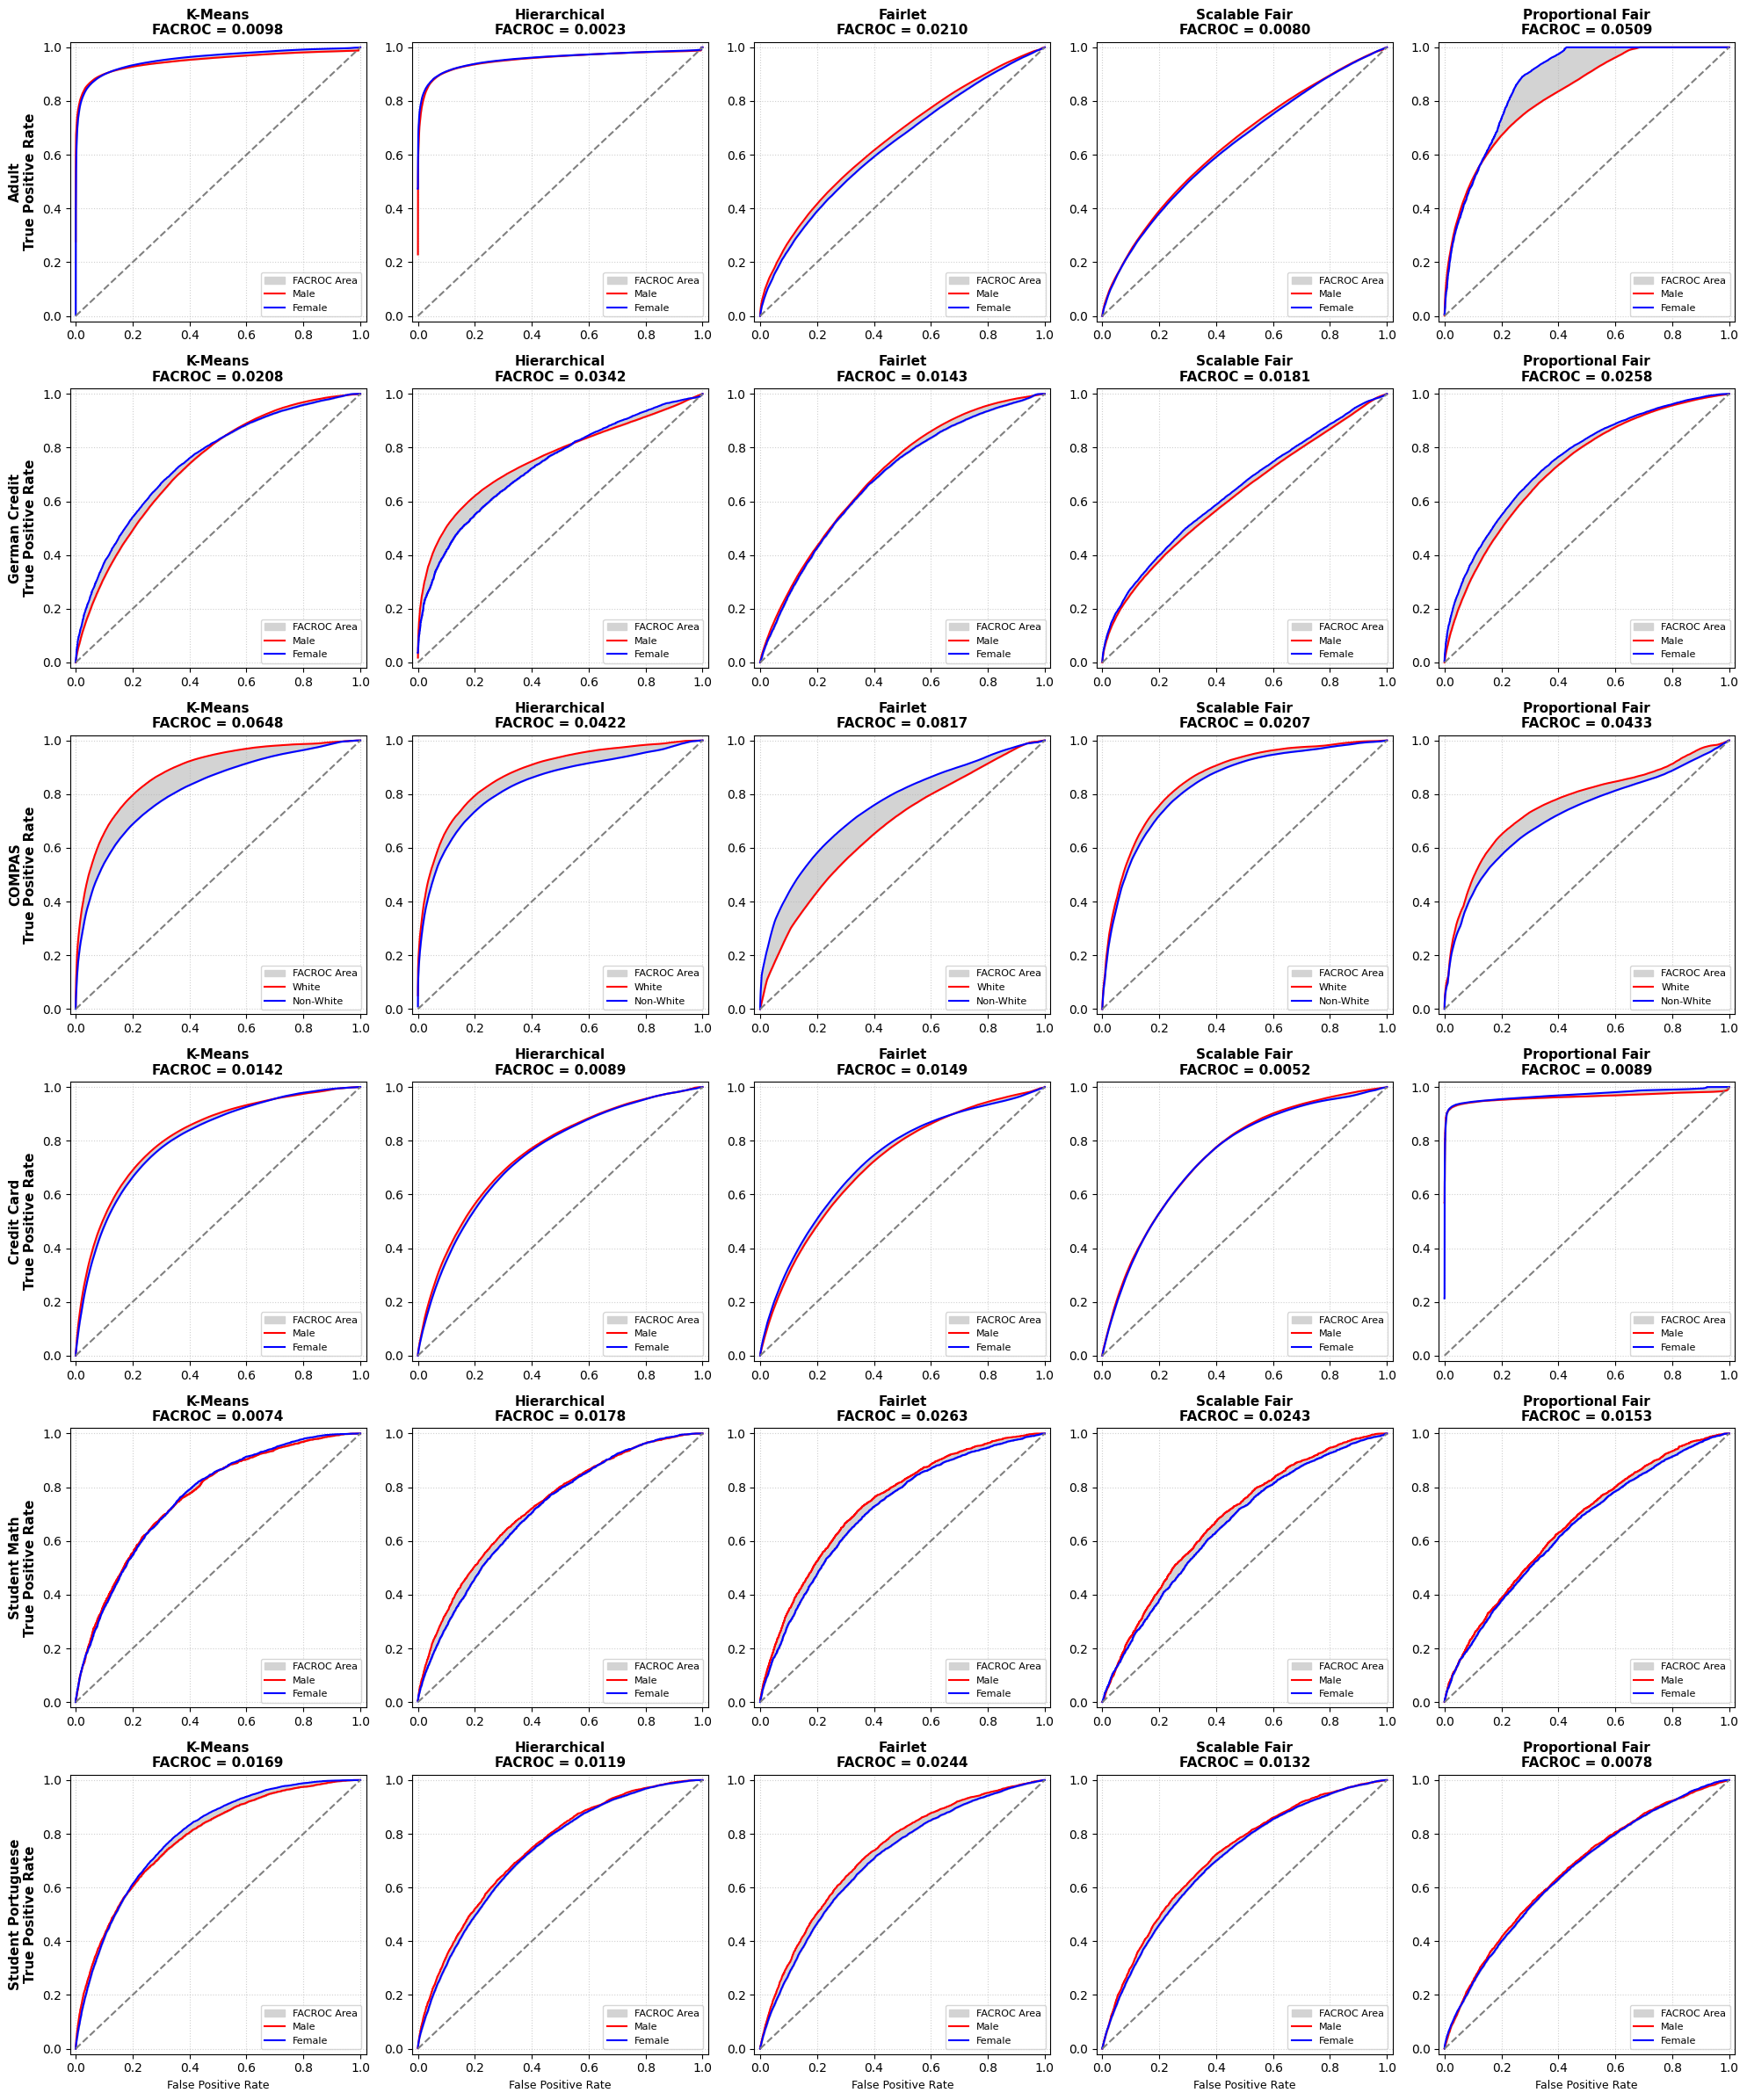

In [4]:
# Generate the large 6 rows x 5 columns grid of ROC curves
fig, axes = plt.subplots(len(datasets), len(methods), figsize=(20, 24))

for r_idx, ds in enumerate(datasets):
    dataset_name = ds["name"]
    # Skip if we don't have results for this dataset
    if dataset_name not in all_roc_results or not all_roc_results[dataset_name]:
        continue
        
    for c_idx, method_name in enumerate(methods.keys()):
        ax = axes[r_idx, c_idx]
        
        roc_data = all_roc_results[dataset_name][method_name]
        p_roc = roc_data["p_roc"]
        np_roc = roc_data["np_roc"]
        score = roc_data["score"]
        
        # Plot ROC curves and shaded area
        ax.fill_between(np_roc["x"], np_roc["y"], p_roc["y"], color="lightgrey", label="FACROC Area")
        ax.plot(np_roc["x"], np_roc["y"], color="red", linewidth=1.5, label=ds["np_label"])
        ax.plot(p_roc["x"], p_roc["y"], color="blue", linewidth=1.5, label=ds["p_label"])
        ax.plot([0, 1], [0, 1], color="grey", linestyle="--")
        
        ax.set_title(f"{method_name}\nFACROC = {score:.4f}", fontweight="bold", fontsize=11)
        
        # Set labels for outer subplots
        if r_idx == len(datasets) - 1:
            ax.set_xlabel("False Positive Rate", fontsize=9)
        if c_idx == 0:
            ax.set_ylabel(f"{dataset_name}\nTrue Positive Rate", fontsize=11, fontweight="bold")
            
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()